In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohamedreda3/bengaluru-house-prices/bengaluru_house_prices.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/mohamedreda3/bengaluru-house-prices/bengaluru_house_prices.csv')

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df.shape

(13320, 9)

In [4]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [5]:
df.describe()


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [11]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(529)

In [7]:
for col in df.columns:
    print(col, ":", df[col].nunique())

area_type : 4
availability : 81
location : 1305
size : 31
society : 2688
total_sqft : 2117
bath : 19
balcony : 4
price : 1994


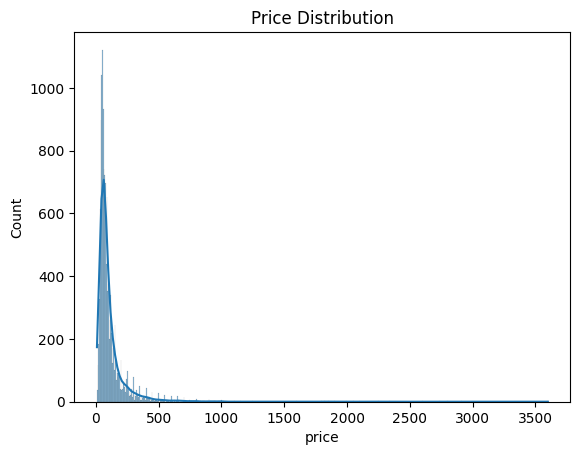

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['price'], kde=True)
plt.title('Price Distribution')
plt.show()

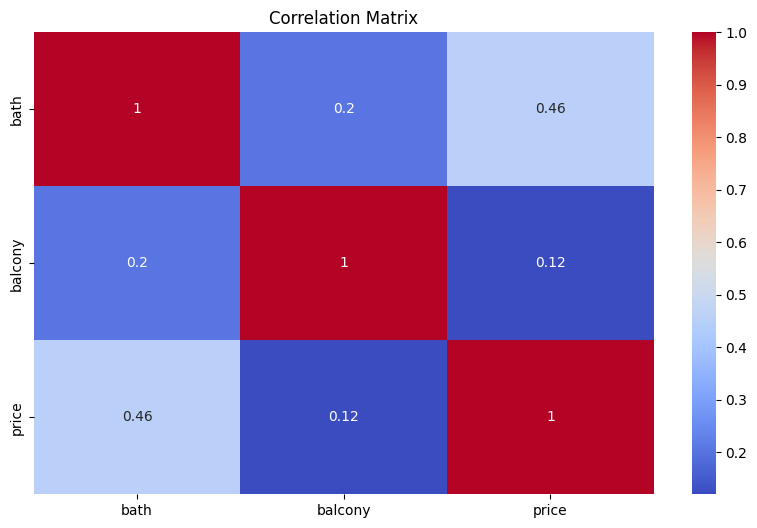

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [13]:
df['location'] = df['location'].fillna(df['location'].mode()[0])
df['size'] = df['size'].fillna(df['size'].mode()[0])
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

In [14]:
df.isnull().sum()

area_type          0
availability       0
location           0
size               0
society         5502
total_sqft         0
bath               0
balcony            0
price              0
dtype: int64

In [15]:
df['bhk'] = df['size'].str.extract('(\d+)').astype(float)

df[['size', 'bhk']].head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_58/3505220659.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['bhk'] = df['size'].str.extract('(\d+)').astype(float)


,size,bhk
0,2 BHK,2.0
1,4 Bedroom,4.0
2,3 BHK,3.0
3,3 BHK,3.0
4,2 BHK,2.0


In [16]:
df = df.drop('size', axis=1)

In [17]:
df['total_sqft'] = pd.to_numeric(
    df['total_sqft'],
    errors='coerce'
)

In [18]:
df['total_sqft'] = df['total_sqft'].fillna(df['total_sqft'].median())

In [19]:
df = pd.get_dummies(df, columns=['location'], drop_first=True)

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Convert all categorical columns to numerical
categorical_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create and Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 37.63222608717123
MSE: 8793.93868944177
RMSE: 93.77600273759684
R2 Score: 0.5869555459598002



**Deep Learning**

In [26]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and Target
X = df.drop('price', axis=1)
y = df['price']

# Convert categorical columns to numerical
categorical_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Make sure all data is numeric
X = X.astype(float)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build Neural Network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Prediction
y_pred = model.predict(X_test).ravel()

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-21 12:17:46.339475: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 25174.4922 - mae: 84.9260 - val_loss: 25863.3594 - val_mae: 74.2905
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 15679.6738 - mae: 56.4464 - val_loss: 20112.7656 - val_mae: 56.9776
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 10652.1328 - mae: 42.6847 - val_loss: 16148.8701 - val_mae: 45.1112
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7750.0737 - mae: 35.7225 - val_loss: 16893.6426 - val_mae: 52.5186
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6840.2739 - mae: 35.4795 - val_loss: 36031.1172 - val_mae: 95.1203
Epoch 6/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7562.0137 - mae: 42.2097 - val_loss: 54701.3164 - val_mae: 118.1262
Epoch 7/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5813.2939 - mae: 33.4901 - val_loss: 125208.5078 - val_mae: 171.2600
Epoch 8/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5128.0669 - mae: 29.1461 - val_loss: 145050.2